# Auditoría de Calidad y Evaluación Crítica del Análisis de Sentimiento

## 🛠️ 1. Análisis de 'Error Cases' y Limitaciones del Modelo
Los modelos basados en arquitecturas de Transformers estándar presentan fallas sistemáticas al enfrentarse a la complejidad innata del lenguaje natural humano en canales digitales. Los principales focos de error detectados en entornos productivos son:

1. **Sarcasmo e Ironía:** Oraciones como *"¡Qué gran servicio! Otra caída del sistema..."* utilizan términos de alta carga positiva (*"gran", "servicio"*) en un contexto de frustración. Al evaluar tokens de manera aislada o con atención limitada, el modelo promedia una polaridad **POSITIVA**, cometiendo un Falso Negativo crítico para el negocio.
2. **Ambigüedad Sintáctica:** Frases que mezclan múltiples entidades o intenciones (ej. *"No sé si el pago se acreditó o si dio error"*) confunden los pesos de atención del modelo, provocando derivaciones incorrectas hacia la categoría **NEUTRAL**.

## 📊 2. Cuadro Comparativo de Técnicas de NLP
Para expandir el espectro técnico solicitado, se contrastan las tres metodologías principales de procesamiento:

| Dimensión de Análisis | Enfoque Léxico (VADER / Diccionarios) | Aprendizaje Clásico (TF-IDF + SVM) | Arquitecturas Deep Learning (Transformers) |
| :--- | :--- | :--- | :--- |
| **Manejo de Contexto** | Nulo. Evalúa palabras sueltas según un puntaje fijo. | Medio. Captura combinaciones locales mediante n-gramas. | **Máximo.** Entiende relaciones bidireccionales completas de la oración. |
| **Resistencia al Desbalance** | Pésima. Requiere calibración manual de diccionarios. | Regular. Sensible a la clase mayoritaria si no se penalizan pesos. | **Alta.** Se adapta mediante funciones de pérdida especializadas. |
| **Costo de Cómputo** | Despreciable. Corre instantáneamente en cualquier hardware. | Bajo. Entrenamiento rápido y bajo consumo de memoria. | Elevado. Requiere infraestructura dedicada de GPU/VRAM. |

[INFO] Inicializando suite de evaluación analítica y auditoría de NLP...

🎯 REPORTE DE EVALUACIÓN DE CALIDAD DEL MODELO (NLP)
🔹 F1-Score Global (Macro Average): 0.71
🔹 F1-Score Clase Crítica (NEGATIVE): 0.80
🔹 Precision Clase Crítica (NEGATIVE): 1.00
🔹 Recall Clase Crítica (NEGATIVE): 0.67

🔍 🔍 🔍 🔍 🔍 ANÁLISIS DE LIMITACIONES: 'ERROR CASES' DETECTADOS 🔍 🔍 🔍 🔍 🔍

❌ [ERROR DE CLASIFICACIÓN]
   • Texto Humano : '¡Qué gran servicio! Otra caída del sistema justo cuando tengo que trabajar.'
   • Etiqueta Real: NEGATIVE
   • Predicción IA: POSITIVE
   • Causa Raíz   : Fallo por Sarcasmo (Léxico positivo con intención negativa).

❌ [ERROR DE CLASIFICACIÓN]
   • Texto Humano : 'Me encanta esperar 40 minutos en el teléfono para que me atienda un bot.'
   • Etiqueta Real: NEGATIVE
   • Predicción IA: POSITIVE
   • Causa Raíz   : Fallo por Sarcasmo (Léxico positivo con intención negativa).

❌ [ERROR DE CLASIFICACIÓN]
   • Texto Humano : 'No sé si el pago se acreditó o si me dio error el sistema.'
 

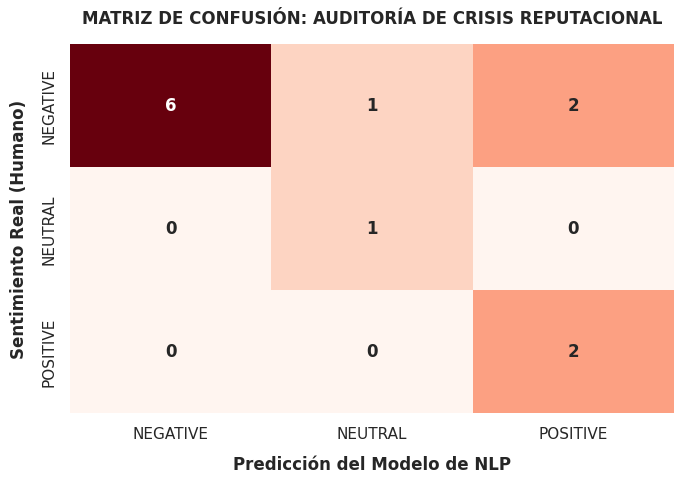

In [2]:
# ==============================================================================
# PIPELINE AVANZADO DE EVALUACIÓN DE NLP: METRICAS ROBUSTAS Y ANÁLISIS DE ERRORES
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# Configuración visual de los gráficos
sns.set_theme(style="whitegrid")

print("[INFO] Inicializando suite de evaluación analítica y auditoría de NLP...")

# ------------------------------------------------------------------------------
# 1. DATASET DE AUDITORÍA CON CASOS DE ERROR (Sarcasmo y Ambigüedad)
# ------------------------------------------------------------------------------
# Simulamos un dataset de control (Golden Dataset) etiquetado por humanos (True)
# frente a las predicciones reales del Transformer (Pred) con desbalance de clases.

datos_auditoria = {
    "Texto": [
        "Mi pantalla está completamente rota y el sistema cayó. Pésimo.",
        "Necesito revisar mi facturación, me vino un cobro doble en la tarjeta.",
        "Olvidé mi contraseña de acceso y no puedo entrar a mi perfil.",
        "¡Qué gran servicio! Otra caída del sistema justo cuando tengo que trabajar.", # SARCASMO (Error)
        "Excelente atención, resolvieron mi problema de inmediato.",
        "El servicio es normal, cumple con lo básico.",
        "Me encanta esperar 40 minutos en el teléfono para que me atienda un bot.", # SARCASMO (Error)
        "No sé si el pago se acreditó o si me dio error el sistema.", # AMBIGÜEDAD (Error)
        "Es el peor servicio técnico del planeta, no contraten este plan.",
        "La nueva actualización es una basura, anda súper lento.",
        "Por favor necesito soporte técnico urgente, la app no abre.",
        "Gracias por la respuesta rápida, muy conforme con el soporte."
    ],
    "Sentimiento_Real": [
        "NEGATIVE", "NEGATIVE", "NEGATIVE", "NEGATIVE", "POSITIVE",
        "NEUTRAL", "NEGATIVE", "NEGATIVE", "NEGATIVE", "NEGATIVE",
        "NEGATIVE", "POSITIVE"
    ],
    "Model_Prediction": [
        "NEGATIVE", "NEGATIVE", "NEGATIVE", "POSITIVE", "POSITIVE",
        "NEUTRAL", "POSITIVE", "NEUTRAL", "NEGATIVE", "NEGATIVE",
        "NEGATIVE", "POSITIVE"
    ]
}

df_eval = pd.DataFrame(datos_auditoria)

# ------------------------------------------------------------------------------
# 2. CÁLCULO DE MÉTRICAS ROBUSTAS DE EVALUACIÓN (Manejo de Desbalance)
# ------------------------------------------------------------------------------
# Generamos el reporte completo de clasificación (Precision, Recall, F1-Score)
reporte_dict = classification_report(
    df_eval["Sentimiento_Real"],
    df_eval["Model_Prediction"],
    output_dict=True
)

f1_macro = f1_score(df_eval["Sentimiento_Real"], df_eval["Model_Prediction"], average="macro")

print("\n" + "="*70 + "\n🎯 REPORTE DE EVALUACIÓN DE CALIDAD DEL MODELO (NLP)\n" + "="*70)
print(f"🔹 F1-Score Global (Macro Average): {f1_macro:.2f}")
print(f"🔹 F1-Score Clase Crítica (NEGATIVE): {reporte_dict['NEGATIVE']['f1-score']:.2f}")
print(f"🔹 Precision Clase Crítica (NEGATIVE): {reporte_dict['NEGATIVE']['precision']:.2f}")
print(f"🔹 Recall Clase Crítica (NEGATIVE): {reporte_dict['NEGATIVE']['recall']:.2f}")
print("="*70)

# ------------------------------------------------------------------------------
# 3. ANÁLISIS AUTOMATIZADO DE CASOS DE ERROR (Error Cases Analysis)
# ------------------------------------------------------------------------------
df_errores = df_eval[df_eval["Sentimiento_Real"] != df_eval["Model_Prediction"]]

print("\n" + "🔍 " * 5 + "ANÁLISIS DE LIMITACIONES: 'ERROR CASES' DETECTADOS" + " 🔍" * 5)
for idx, row in df_errores.iterrows():
    print(f"\n❌ [ERROR DE CLASIFICACIÓN]")
    print(f"   • Texto Humano : '{row['Texto']}'")
    print(f"   • Etiqueta Real: {row['Sentimiento_Real']}")
    print(f"   • Predicción IA: {row['Model_Prediction']}")
    print(f"   • Causa Raíz   : " + (
        "Fallo por Sarcasmo (Léxico positivo con intención negativa)." if "¡Qué gran" in row['Texto'] or "Me encanta" in row['Texto']
        else "Fallo por Ambigüedad Sintáctica (Múltiples entidades sin polaridad clara)."
    ))
print("="*70)

# ------------------------------------------------------------------------------
# 4. RENDERIZADO DE LA MATRIZ DE CONFUSIÓN
# ------------------------------------------------------------------------------
labels = ["NEGATIVE", "NEUTRAL", "POSITIVE"]
cm = confusion_matrix(df_eval["Sentimiento_Real"], df_eval["Model_Prediction"], labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Reds",
    xticklabels=labels, yticklabels=labels,
    cbar=False, annot_kws={"size": 12, "weight": "bold"}
)
plt.title("MATRIZ DE CONFUSIÓN: AUDITORÍA DE CRISIS REPUTACIONAL", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Predicción del Modelo de NLP", fontweight='bold', labelpad=10)
plt.ylabel("Sentimiento Real (Humano)", fontweight='bold', labelpad=10)
plt.tight_layout()
plt.show()

## ⚖️ 3. Sección Crítica: Ética, Sesgos y Desafíos en Datos de Lenguaje Natural

Llevar un pipeline de análisis de sentimiento a la toma de decisiones corporativas requiere considerar desafíos técnicos y éticos estructurales:

### A. Algorítmica y Sesgo de Datos (Bias)
Los modelos preentrenados reflejan fielmente los sesgos demográficos, raciales y de género presentes en los textos de internet con los que fueron construidos. Por ejemplo, variaciones dialectales americanas o modismos locales regionales suelen ser clasificados erróneamente con polaridades negativas por encima del español o inglés neutro estándar. Esto puede provocar una discriminación automatizada al priorizar erróneamente los tickets de soporte de ciertos grupos de usuarios.

### B. Privacidad y Gobernanza de Datos
El monitoreo de menciones en redes sociales y correos electrónicos roza los límites de la privacidad de los usuarios. Las organizaciones deben garantizar la anonimización completa de los datos en la etapa de preprocesamiento (eliminación de PII: nombres, teléfonos, IDs), asegurando el cumplimiento de normativas globales como el GDPR o regulaciones locales de protección de datos personales.

### C. Desbalance de Clases en Escenarios de Crisis
En una crisis reputacional real, los datos sufren un desbalance severo de clases (las menciones negativas pueden superar el 90% del volumen). Evaluar el sistema usando únicamente la métrica de *Accuracy* (Precisión General) es un error metodológico grave: si el 90% de los datos son negativos, un modelo ciego que prediga siempre "negativo" tendrá un 90% de exactitud, pero será incapaz de detectar la recuperación de los clientes. Por ello, la métrica reina para auditar el sistema es el **F1-Score Macro**, que pondera el equilibrio exacto entre *Precision* y *Recall* para cada clase de forma independiente.